# Daily Data 分析ノートブック

このノートブックでは、`logs/daily_data.json` に記録された日々の目標、タスク、天気情報などをロードし、分析・可視化を行います。

## 1. ライブラリのインポートと環境設定

データ分析に必要なライブラリをインポートします。視覚化で日本語が文字化けする場合は、`japanize-matplotlib` 等の導入を検討してください。

In [1]:
import sys

print(sys.executable)
!pip install pandas
!pip install matplotlib
!pip install seaborn

/Users/a81906/projects/dialy_data/.venv/bin/python3.11

[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# グラフのスタイル設定
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams["font.family"] = "Hiragino Sans"
# 日本語表示のための設定 (環境に応じてフォントを変更するか japanize-matplotlib を使用してください)
# import japanize_matplotlib  # インストールされている場合

## 2. データの読み込みと前処理

`logs/daily_data.json` は、日付をキーとした辞書形式で保存されています。これを Pandas の DataFrame に変換して分析しやすい形に整形します。

In [35]:
json_path = '../logs/daily_data.json'

with open(json_path, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

records = []
i = 0
for date_str, info in raw_data.items():
    goal = info.get('goal', '')
    tasks = info.get('tasks', [])
    memo = info.get('memo', '')
    city = info.get('city', '')

    # タスクの集計
    total_tasks = len(tasks)
    completed_tasks = sum(1 for t in tasks if t.get('done', False))
    completion_rate = completed_tasks / total_tasks if total_tasks > 0 else np.nan

    # 天気情報の取得（当日日付の天気を優先、なければ最初の天気）
    weather_info = info.get('weather', {})
    today_weather = weather_info.get(date_str, {})
    if not today_weather and weather_info:
        first_key = list(weather_info.keys())[0]
        today_weather = weather_info[first_key]

    weather_desc = today_weather.get('desc', '')
    temp = today_weather.get('temp', np.nan)

    records.append({
        'date': date_str,
        'goal': goal,
        'has_goal': int(bool(goal.strip())),
        'total_tasks': total_tasks,
        'completed_tasks': completed_tasks,
        'completion_rate': completion_rate,
        'memo_length': len(memo.strip()),
        'city': city,
        'weather_desc': weather_desc,
        'temp': temp
    })

df = pd.DataFrame(records)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)


In [10]:
# todo 日付・タスク・doneのdataframe作成
raw_data

{'2025-11-13': {'goal': '',
  'tasks': [],
  'memo': '',
  'city': 'Tokushima',
  'weather': {'2025-11-14': {'desc': '雲', 'temp': 17.68, 'icon': '03d'}}},
 '2025-11-14': {'goal': '徐々に動き出す',
  'tasks': [{'name': 'アプリ作成', 'done': True},
   {'name': 'ブックマーク整理', 'done': False},
   {'name': '瞑想', 'done': False},
   {'name': 'リファクタ', 'done': False},
   {'name': '保存できるようにする', 'done': False}],
  'memo': '',
  'city': 'Tokushima',
  'weather': {'2025-11-14': {'desc': '曇りがち', 'temp': 13.96, 'icon': '04n'},
   '2025-11-15': {'desc': '雲', 'temp': 18.99, 'icon': '03d'}}},
 '2025-11-15': {'goal': '色々掃除する',
  'tasks': [{'id': 1763168780.358311, 'name': '部屋の掃除', 'done': True},
   {'id': 1763169521.407159, 'name': 'ブクマの掃除', 'done': True},
   {'id': 1763169530.215717, 'name': '心の掃除', 'done': True},
   {'id': 1763169537.399893, 'name': 'タスクの掃除', 'done': True},
   {'id': 1763169545.816362, 'name': 'プロジェクトの掃除', 'done': True},
   {'id': 1763171110.857305, 'name': '気持ちの保存出来るようにする', 'done': True},
   {'id': 1

### 2.2 タスク単位のデータフレームの作成

タスクごとの詳細な分析を行うため、日付（`date`）、タスク名（`task_name`）、完了状況（`done`）をカラムに持ち、タスクごとに1行となるデータフレーム `df_tasks` を作成します。

In [11]:
# タスクごとのレコードリストを作成
task_records = []
for date_str, info in raw_data.items():
    tasks = info.get('tasks', [])
    for task in tasks:
        task_name = task.get('name', '')
        task_done = task.get('done', False)

        task_records.append({
            'date': date_str,
            'task_name': task_name,
            'done': task_done
        })

# データフレームの作成と前処理
df_tasks = pd.DataFrame(task_records)
df_tasks['date'] = pd.to_datetime(df_tasks['date'])
df_tasks = df_tasks.sort_values('date').reset_index(drop=True)

# 最初の10行を表示
df_tasks.head(10)

,date,task_name,done
0,2025-11-14,アプリ作成,True
1,2025-11-14,ブックマーク整理,False
2,2025-11-14,瞑想,False
3,2025-11-14,リファクタ,False
4,2025-11-14,保存できるようにする,False
5,2025-11-15,タブ整理,True
6,2025-11-15,セキュリティ見直し,False
7,2025-11-15,読書,False
8,2025-11-15,ストレッチ,False
9,2025-11-15,気持ちの保存出来るようにする,True


In [14]:
df_tasks.info()

<class 'pandas.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       1260 non-null   datetime64[us]
 1   task_name  1260 non-null   str           
 2   done       1260 non-null   bool          
dtypes: bool(1), datetime64[us](1), str(1)
memory usage: 21.0 KB


In [34]:
result = (
    df_tasks.groupby([
        pd.Grouper(key="date", freq="ME"),
        "task_name"
    ])
    .size()
    .reset_index(name="count")
)

result

,date,task_name,count
0,2025-11-30,GitHubにアップロード,1
1,2025-11-30,LLM導入,1
2,2025-11-30,PC情報整理,1
3,2025-11-30,SNS方針,1
4,2025-11-30,SNS運用計画書,1
...,...,...,...
897,2026-06-30,面接対策,1
898,2026-06-30,面談,1
899,2026-06-30,面談情報整理,1
900,2026-06-30,面談準備,1


## 3. 基本的な統計情報の確認

データの全体像を確認します。

In [4]:
print(f"データの総日数: {len(df)} 日")
print(f"期間: {df['date'].min().strftime('%Y-%m-%d')} 〜 {df['date'].max().strftime('%Y-%m-%d')}")
print("\n--- 欠損値とデータ型の情報 ---")
print(df.info())
print("\n--- 数値カラムの要約統計量 ---")
df.describe().T

データの総日数: 221 日
期間: 2025-11-13 〜 2026-06-23

--- 欠損値とデータ型の情報 ---
<class 'pandas.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             221 non-null    datetime64[us]
 1   goal             221 non-null    str           
 2   has_goal         221 non-null    int64         
 3   total_tasks      221 non-null    int64         
 4   completed_tasks  221 non-null    int64         
 5   completion_rate  210 non-null    float64       
 6   memo_length      221 non-null    int64         
 7   city             221 non-null    str           
 8   weather_desc     221 non-null    str           
 9   temp             186 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(4), str(3)
memory usage: 17.4 KB
None

--- 数値カラムの要約統計量 ---


,count,mean,min,25%,50%,75%,max,std
date,221,2026-03-04 00:19:32.850678,2025-11-13 00:00:00,2026-01-08 00:00:00,2026-03-04 00:00:00,2026-04-28 00:00:00,2026-06-23 00:00:00,NaN
has_goal,221.0,0.39819,0.0,0.0,0.0,1.0,1.0,0.490636
total_tasks,221.0,5.701357,0.0,4.0,6.0,8.0,13.0,2.863794
completed_tasks,221.0,3.705882,0.0,2.0,4.0,6.0,10.0,2.666188
completion_rate,210.0,0.598607,0.0,0.428571,0.666667,0.8,1.0,0.285197
memo_length,221.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
temp,186.0,11.747903,0.96,6.96,11.46,15.96,25.01,5.749033


## 4. 目標とタスクの分析

### 4.1 目標の設定状況
目標を設定した日の割合を集計します。

In [5]:
goal_counts = df['has_goal'].value_counts(normalize=True) * 100
print(f"目標を設定した日の割合: {goal_counts.get(1, 0):.2f}%")
print(f"目標を設定しなかった日の割合: {goal_counts.get(0, 0):.2f}%")

目標を設定した日の割合: 39.82%
目標を設定しなかった日の割合: 60.18%


### 4.2 タスクの傾向
タスク数とタスク完了率の推移をプロットします。

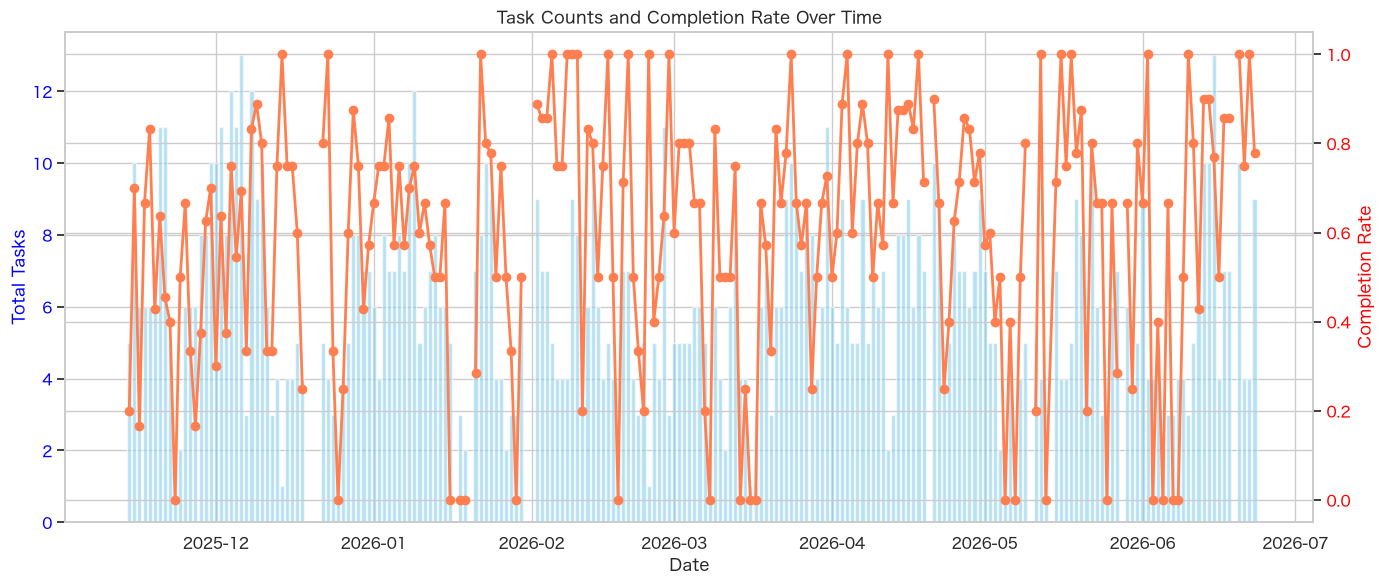

In [6]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# タスク数の推移 (棒グラフ)
color = 'skyblue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Tasks', color='blue')
ax1.bar(df['date'], df['total_tasks'], color=color, alpha=0.6, label='Total Tasks')
ax1.tick_params(axis='y', labelcolor='blue')

# タスク完了率の推移 (折れ線グラフ)
ax2 = ax1.twinx()
color = 'coral'
ax2.set_ylabel('Completion Rate', color='red')
ax2.plot(df['date'], df['completion_rate'], color=color, marker='o', linewidth=2, label='Completion Rate')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(-0.05, 1.05)

plt.title('Task Counts and Completion Rate Over Time')
fig.tight_layout()
plt.show()

### 4.3 月ごとのタスク集計

月ごとのタスクの総数、完了数、および完了率を集計し、その推移を可視化します。

--- 月ごとのタスク集計 ---
   date  total_days  total_tasks  completed_tasks  completion_rate year_month_str
2025-11          18          115               58         0.504348        2025-11
2025-12          30          183              114         0.622951        2025-12
2026-01          31          173              106         0.612717        2026-01
2026-02          28          148              110         0.743243        2026-02
2026-03          31          178              109         0.612360        2026-03
2026-04          30          194              146         0.752577        2026-04
2026-05          30          138               84         0.608696        2026-05
2026-06          23          131               92         0.702290        2026-06


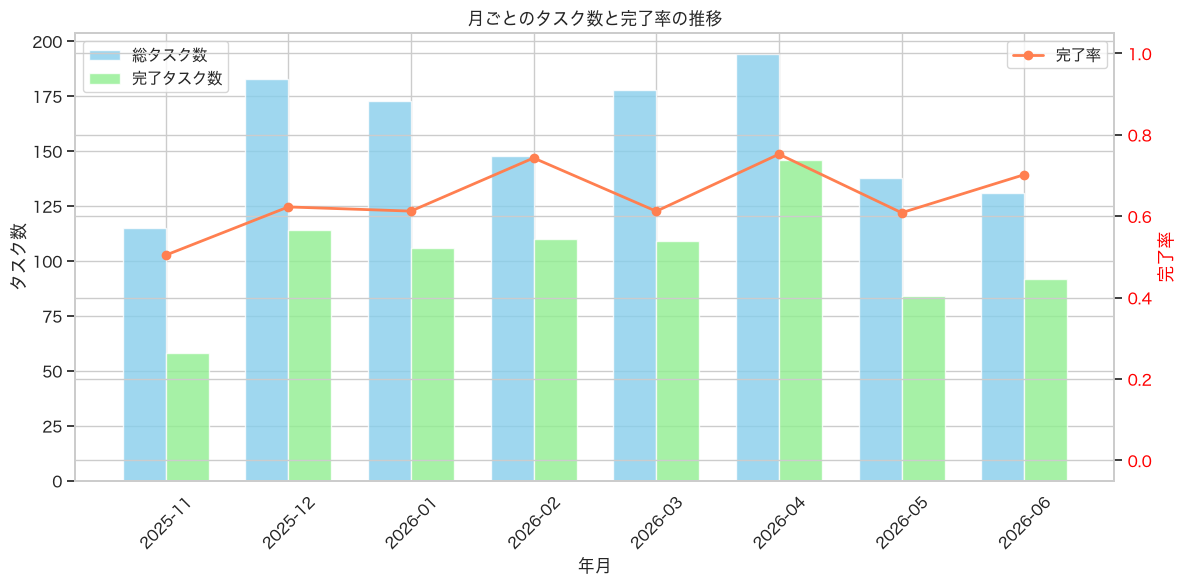

In [7]:
# 月ごとにグループ化して集計
df_monthly = df.groupby(df['date'].dt.to_period('M')).agg(
    total_days=('date', 'count'),
    total_tasks=('total_tasks', 'sum'),
    completed_tasks=('completed_tasks', 'sum'),
).reset_index()

# 月ごとの完了率を計算
df_monthly['completion_rate'] = df_monthly['completed_tasks'] / df_monthly['total_tasks']
# 年月の文字列表現
df_monthly['year_month_str'] = df_monthly['date'].astype(str)

print("--- 月ごとのタスク集計 ---")
print(df_monthly.to_string(index=False))

# 可視化
fig, ax1 = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_monthly))
width = 0.35

# タスク数と完了タスク数の推移 (棒グラフ)
ax1.bar(x - width/2, df_monthly['total_tasks'], width, label='総タスク数', color='skyblue', alpha=0.8)
ax1.bar(x + width/2, df_monthly['completed_tasks'], width, label='完了タスク数', color='lightgreen', alpha=0.8)
ax1.set_xlabel('年月')
ax1.set_ylabel('タスク数')
ax1.set_xticks(x)
ax1.set_xticklabels(df_monthly['year_month_str'], rotation=45)
ax1.legend(loc='upper left')

# タスク完了率の推移 (折れ線グラフ)
ax2 = ax1.twinx()
ax2.plot(x, df_monthly['completion_rate'], color='coral', marker='o', linewidth=2, label='完了率')
ax2.set_ylabel('完了率', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(-0.05, 1.05)
ax2.legend(loc='upper right')

plt.title('月ごとのタスク数と完了率の推移')
fig.tight_layout()
plt.show()

## 5. 天気とタスク完了率・完了数の関連分析


### 5.1天気とタスク完了率・完了数の関係
天候によってタスク完了率に違いがあるかを分析します。

In [8]:
weather_completion = df.groupby('weather_desc')['completion_rate'].agg(['count', 'mean', 'median'])
print("--- 天気別のタスク完了率集計 ---")
print(weather_completion.sort_values(by='mean', ascending=False))

weather_completion_sum = df.groupby('weather_desc')['completed_tasks'].agg(['count', 'mean', 'median'])
print("--- 天気別のタスク完了数集計 ---")
print(weather_completion_sum.sort_values(by='mean', ascending=False))

# # 箱ひげ図で可視化
# plt.figure(figsize=(12, 6))
# sns.boxplot(data=df, x='weather_desc', y='completion_rate', palette='Set3', hue="weather_desc",)
# plt.title('Task Completion Rate by Weather Condition')
# plt.xlabel('Weather')
# plt.ylabel('Completion Rate')
# plt.xticks(rotation=45)
# plt.show()

--- 天気別のタスク完了率集計 ---
              count      mean    median
weather_desc                           
小雪                1  1.000000  1.000000
晴天                6  0.840344  0.788889
霧                 1  0.800000  0.800000
適度な雨              2  0.770833  0.770833
厚い雲               9  0.654630  0.666667
弱いにわか雨            6  0.643519  0.666667
雲                22  0.627417  0.750000
強い雨               7  0.625943  0.666667
薄い雲              55  0.583186  0.600000
曇りがち             67  0.572497  0.666667
                 33  0.568291  0.666667
小雨                1  0.200000  0.200000
--- 天気別のタスク完了数集計 ---
              count      mean  median
weather_desc                         
適度な雨              2  5.500000     5.5
晴天                7  4.571429     5.0
強い雨               7  4.285714     4.0
弱いにわか雨            6  4.166667     4.0
薄い雲              56  4.071429     4.0
小雪                1  4.000000     4.0
霧                 1  4.000000     4.0
雲                23  3.695652     3.0
                 3

### 5.2気温とタスク完了率・完了数の相関
気温とタスク完了率の間に相関があるかを散布図で確認します。

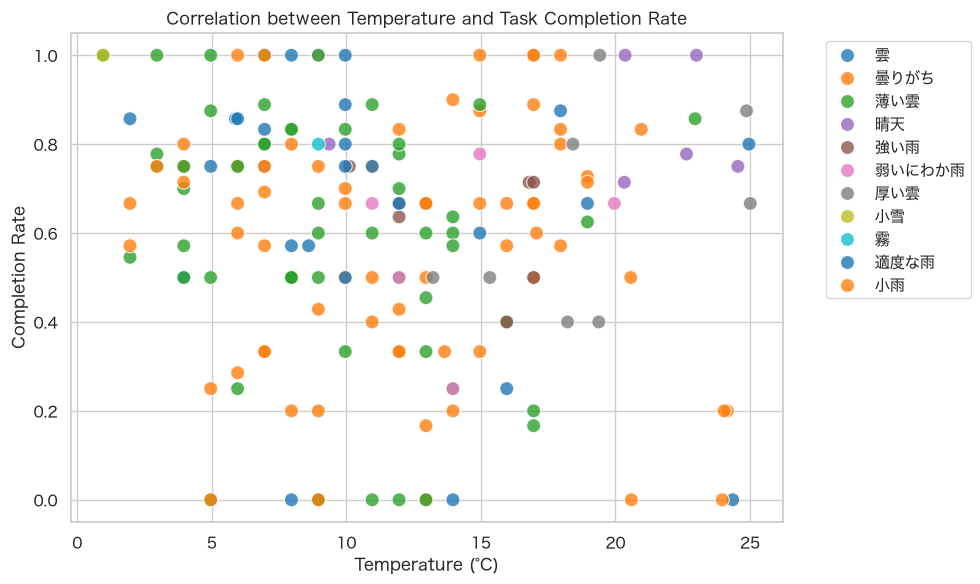


--- 相関係数行列 ---
                     temp  completion_rate  total_tasks  completed_tasks
temp             1.000000        -0.087681    -0.088972        -0.105512
completion_rate -0.087681         1.000000     0.415617         0.754836
total_tasks     -0.088972         0.415617     1.000000         0.873078
completed_tasks -0.105512         0.754836     0.873078         1.000000


In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='temp', y='completion_rate', hue='weather_desc', palette='tab10', s=100, alpha=0.8)
plt.title('Correlation between Temperature and Task Completion Rate')
plt.xlabel('Temperature (°C)')
plt.ylabel('Completion Rate')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

correlation = df[['temp', 'completion_rate', 'total_tasks', 'completed_tasks']].corr()
print("\n--- 相関係数行列 ---")
print(correlation)

In [5]:
import pandas as pd
import sqlite3


conn = sqlite3.connect("../data/task_rpg.db")
cursor = conn.cursor()

df = pd.read_sql_query(
    "SELECT * FROM task_logs",
    conn
)

df.head()

,id,date,task_name,done
0,1,2026-06-25,筋トレ,1
1,2,2026-06-25,筋トレ,1
2,3,2026-06-25,筋トレ,1
3,4,2026-06-25,筋トレ,1
4,5,2026-06-25,筋トレ,1


In [8]:
df[20:].head(20)

,id,date,task_name,done
20,21,2025-11-15,タブ整理,1
21,22,2025-11-16,漏洩した可能性があるパスワード修正,0
22,23,2025-11-16,重複しているパスワード修正,0
23,24,2025-11-16,瞑想,0
24,25,2025-11-16,読書,1
25,26,2025-11-16,ワンパス系の設定,0
26,27,2025-11-16,クロームの自動入力切る,0
27,28,2025-11-17,保管庫10個,1
28,29,2025-11-17,保管庫20個,1
29,30,2025-11-17,残り100件まで減らす,1


In [9]:
df[100:].head(20)

,id,date,task_name,done
100,101,2025-11-28,お参り,1
101,102,2025-11-28,github綺麗に,0
102,103,2025-11-28,コミュ力向上委員会,0
103,104,2025-11-29,未知のリモートツールが入ってるか確認,1
104,105,2025-11-29,ログイン通知確認,1
105,106,2025-11-29,github見やすくする,1
106,107,2025-11-29,２段階認証整理,1
107,108,2025-11-29,まずは感情表現から,0
108,109,2025-11-29,SNS運用計画書,0
109,110,2025-11-29,感情ログのバグ修正,0
